# **Projeto: Agroclima Café**
## Risco climático e produção de café em Lavras-MG
### Cauã Fernando

-----

Pesquisa exploratória sobre como eventos climáticos (geada, chuva excessiva, veranico) se relacionam com a produção cafeeira no município de Lavras-MG, usando dados históricos reais de clima (1974-2024) e produção agrícola. É o passo 1 de um objetivo maior: construir a base de dados e análise que sustente, no futuro, um SaaS para cooperativas de café identificarem as melhores janelas de colheita e plantio.

Este notebook é a versão consolidada, em um único arquivo, da pesquisa completa — o pipeline real (coleta → limpeza → EDA → relatório), com código reprodutível passo a passo, vive em `notebooks/` e `src/`; a documentação de escopo e o relatório em texto ficam em `docs/`.

-----

## Bibliotecas e funções do projeto

In [1]:
import sys
sys.path.append(".")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from src.coleta import coletar_clima, coletar_producao_cafe, coletar_geada_estacao_83687
from src.risco import resumo_anual_risco, contar_sequencias_secas

sns.set_theme(style="whitegrid")
ANO_INICIO, ANO_FIM = 1974, 2024


-----

## 1. Coleta dos Dados

Três fontes, todas de acesso público e gratuito, sem necessidade de conta/login:

### 1.1 Clima — Open-Meteo

Temperatura máxima/mínima e precipitação diárias, via Archive API (reanálise histórica).

In [2]:
df_clima = coletar_clima(ANO_INICIO, ANO_FIM)
df_clima["time"] = pd.to_datetime(df_clima["time"])
df_clima.head()


200
Arquivo salvo em data/raw/lavras_clima_1974_2024.csv


,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,1974-01-01,25.1,19.3,24.6
1,1974-01-02,25.6,18.7,10.4
2,1974-01-03,26.4,18.4,0.0
3,1974-01-04,26.2,18.2,0.3
4,1974-01-05,26.8,17.7,2.5


### 1.2 Produção cafeeira — IBGE/SIDRA

Área colhida, quantidade produzida e rendimento médio de café, nível municipal, tabela 1613 (Produção Agrícola Municipal). Avaliamos a CONAB antes, mas ela só tem série por região produtora ("Sul de Minas"), não por município.

In [3]:
df_producao = coletar_producao_cafe(ANO_INICIO, ANO_FIM)
df_producao.head()


200
Arquivo salvo em data/raw/lavras_producao_cafe_1974_2024.csv


,ano,quantidade_produzida_t,rendimento_medio_kg_ha,area_colhida_ha
0,1974,2880,2000,1440
1,1975,1197,750,1596
2,1976,3302,1914,1725
3,1977,3120,1600,1950
4,1978,4208,1600,2630


### 1.3 Geada — estação real 83687 (a peça que faltava)

O Open-Meteo é reanálise em grade (~25-31km) — suaviza extremos locais e, nos primeiros 25 anos testados (2000-2024), nunca registrou um único dia de geada em Lavras. Tentamos destravar dado de estação real via BDMEP do INMET (conta criada, pedido de exportação nunca respondido) e via API pública do INMET (bloqueou acesso automatizado). A solução veio de outro lugar: o projeto **BR-DWGD** (Xavier et al., 2022), que constrói uma grade climática nacional a partir de estações reais e publica também os **dados brutos de observação por estação** que usou — incluindo a estação 83687 (Lavras/UFLA), sem precisar de conta nem baixar a grade inteira (~7GB).

In [4]:
df_geada_estacao = coletar_geada_estacao_83687(ANO_INICIO, ANO_FIM)
df_geada_estacao["time"] = pd.to_datetime(df_geada_estacao["time"])
df_geada_estacao.head()


Arquivo salvo em data/raw/lavras_geada_estacao_83687_1974_2024.csv


,time,tmin_estacao
4748,1974-01-01,17.900000
4749,1974-01-02,19.200001
4750,1974-01-03,18.400000
4751,1974-01-04,17.600000
4752,1974-01-05,18.200001


-----

## 2. Limpeza dos Dados

Checagem de valores faltantes/duplicados, buracos no calendário e consistência lógica (ex.: temperatura máxima nunca menor que a mínima, produção nunca negativa) para as três fontes.

In [5]:
print("--- Clima (Open-Meteo) ---")
print("Faltando:", df_clima.isna().sum().sum(), "| Duplicadas:", df_clima.duplicated().sum())
calendario = pd.date_range(df_clima["time"].min(), df_clima["time"].max(), freq="D")
print("Dias faltando no calendário:", len(calendario.difference(df_clima["time"])))
print("Linhas com max < min:", (df_clima["temperature_2m_max"] < df_clima["temperature_2m_min"]).sum())
print("Linhas com chuva negativa:", (df_clima["precipitation_sum"] < 0).sum())


--- Clima (Open-Meteo) ---
Faltando: 0 | Duplicadas: 0
Dias faltando no calendário: 0
Linhas com max < min: 0
Linhas com chuva negativa: 0


In [6]:
print("--- Produção (IBGE/SIDRA) ---")
print("Faltando:", df_producao.isna().sum().sum(), "| Anos duplicados:", df_producao["ano"].duplicated().sum())
colunas_prod = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]
print("Valores negativos:", (df_producao[colunas_prod] < 0).sum().sum())
rendimento_calc = df_producao["quantidade_produzida_t"] * 1000 / df_producao["area_colhida_ha"]
print("Maior diferença rendimento informado x calculado (kg/ha):", (rendimento_calc - df_producao["rendimento_medio_kg_ha"]).abs().max())


--- Produção (IBGE/SIDRA) ---
Faltando: 0 | Anos duplicados: 0
Valores negativos: 0
Maior diferença rendimento informado x calculado (kg/ha): 0.8279569892472978


In [7]:
print("--- Geada (estação 83687) ---")
pct_faltando = df_geada_estacao["tmin_estacao"].isna().mean() * 100
print(f"Faltando: {pct_faltando:.1f}% | Duplicadas:", df_geada_estacao.duplicated().sum())
fora_da_faixa = df_geada_estacao["tmin_estacao"].dropna().between(-10, 40)
print("Valores fora da faixa plausível (-10 a 40°C):", (~fora_da_faixa).sum())

# Junta geada no dataframe de clima (Open-Meteo segue valendo pra chuva/veranico, estação real só pra geada)
df_clima = df_clima.merge(df_geada_estacao[["time", "tmin_estacao"]], on="time", how="left")


--- Geada (estação 83687) ---
Faltando: 3.4% | Duplicadas: 0
Valores fora da faixa plausível (-10 a 40°C): 0


Nenhum problema nas três fontes. Nos dados da estação real, mantemos os valores faltantes como estão (sem interpolar temperatura mínima — isso poderia mascarar ou inventar geada).

-----

## 3. Análise Exploratória

### 3.1 Estatísticas descritivas

In [8]:
df_clima.describe()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,tmin_estacao
count,18628,18628.000000,18628.000000,18628.000000,18002.000000
mean,1999-07-02 12:00:00,24.905943,15.369809,3.383552,15.411673
min,1974-01-01 00:00:00,11.300000,1.500000,0.000000,-0.200000
25%,1986-10-01 18:00:00,23.000000,13.200000,0.000000,13.000000
50%,1999-07-02 12:00:00,25.100000,16.100000,0.200000,16.100000
75%,2012-04-01 06:00:00,27.000000,17.900000,3.800000,18.100000
max,2024-12-31 00:00:00,36.400000,22.100000,90.600000,24.100000
std,NaN,2.962859,3.121473,6.839556,3.281055


- A média da mínima diária é ~15,4°C (plausível para Lavras, ~900m de altitude), mas o valor mínimo absoluto é 1,5°C — já um indício de geada, mesmo na fonte de reanálise.
- Chuva é muito assimétrica: mediana de 0,2mm contra máxima de 90,6mm num único dia — típico do regime de chuvas concentradas em Lavras.

### 3.2 Índices de risco climático

Usando `src/risco.py`, calculamos geada (leve/severa), chuva excessiva e veranico (sequência de ≥10 dias secos consecutivos dentro da estação chuvosa, out-mar) por ano. Geada usa a série da estação real; as outras variáveis usam o Open-Meteo.

In [9]:
resumo = resumo_anual_risco(df_clima, tmin_geada=df_clima["tmin_estacao"])
veranicos = contar_sequencias_secas(df_clima)
resumo.tail(10)


,geada_leve,geada_severa,chuva_excessiva,veranicos
ano,,,,
2015,0,0,0,2
2016,0,0,0,2
2017,0,0,2,3
2018,0,0,0,0
2019,0,0,0,2
2020,0,0,1,0
2021,0,0,0,1
2022,0,0,1,1
2023,0,0,1,1


**Grade x estação, lado a lado**: no mesmo recorte de 51 anos, o Open-Meteo (grade) classifica só 4 dias de geada em 3 anos (1979, 1981, 1994); a estação real classifica **10 dias de geada leve em 6 anos** (1975, 1978, 1979, 1981, 1994, 2000) mais **1 dia de geada severa** (21/07/1981, -0,2°C — a única vez na série inteira abaixo de 0°C). A grade capta os anos mais extremos, mas subestima frequência e severidade, e nunca detecta o único evento severo.

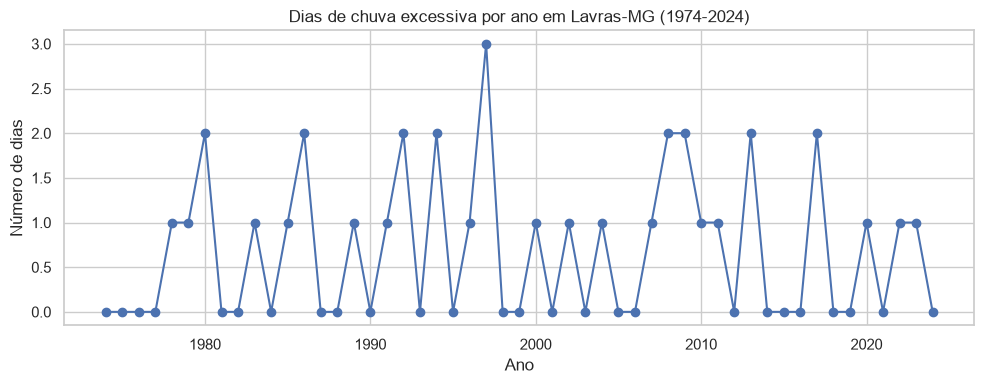

In [10]:
resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG (1974-2024)")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()


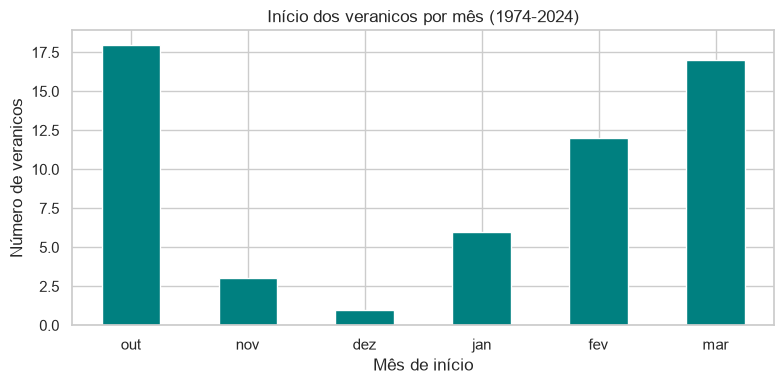

In [11]:
nomes_meses = {10: "out", 11: "nov", 12: "dez", 1: "jan", 2: "fev", 3: "mar"}
inicio_por_mes = veranicos["inicio"].dt.month.value_counts().reindex(nomes_meses.keys(), fill_value=0)
inicio_por_mes.index = inicio_por_mes.index.map(nomes_meses)

inicio_por_mes.plot(kind="bar", figsize=(8, 4), title="Início dos veranicos por mês (1974-2024)", color="teal")
plt.ylabel("Número de veranicos")
plt.xlabel("Mês de início")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


57 veranicos detectados nos 51 anos, concentrados no **início** (outubro, 18 dos 57) e **fim** (fevereiro-março, 29 dos 57) da estação chuvosa. Novembro-janeiro — o núcleo da estação — concentra só 10 dos 57. Um indício de janela historicamente mais estável nesses três meses.

-----

## 4. Clima x Produção: Correlação e Regressão

Pergunta central da pesquisa: existe relação entre os riscos climáticos e a produtividade do café em Lavras? Cruzamos o resumo anual de risco com a produção do IBGE (n=51 anos).

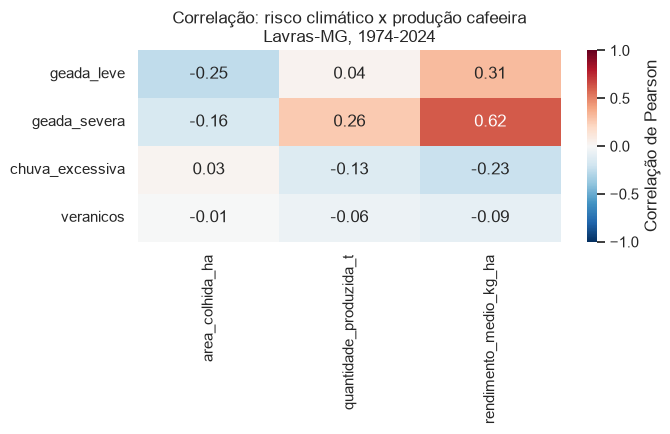

In [12]:
clima_x_producao = resumo.join(df_producao.set_index("ano"), how="inner")

colunas_risco = ["geada_leve", "geada_severa", "chuva_excessiva", "veranicos"]
colunas_producao = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]
corr_cruzada = clima_x_producao.corr(method="pearson").loc[colunas_risco, colunas_producao]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(corr_cruzada, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, cbar_kws={"label": "Correlação de Pearson"})
ax.set_title("Correlação: risco climático x produção cafeeira\nLavras-MG, 1974-2024")
plt.tight_layout()
plt.show()


`geada_leve` e `geada_severa` saltam aos olhos com as maiores correlações (rendimento: r≈+0,31 e r≈+0,62) — mas **positivas**, o oposto do que a agronomia prevê. Antes de acreditar nisso, precisamos investigar — ver seção 4.1. Fora a geada, todas as correlações são fracas (|r| < 0,25); `area_colhida_ha` tem tendência temporal forte (expansão econômica ao longo dos 51 anos), o que pode confundir qualquer correlação que a envolva.

In [13]:
resumo_defasado = resumo.shift(1)
resumo_defasado.columns = [f"{c}_ano_anterior" for c in resumo_defasado.columns]
clima_x_producao_defasada = resumo_defasado.join(df_producao.set_index("ano"), how="inner").dropna()

colunas_risco_defasado = [f"{c}_ano_anterior" for c in colunas_risco]
corr_defasada = clima_x_producao_defasada.corr(method="pearson").loc[colunas_risco_defasado, colunas_producao]
corr_defasada[["rendimento_medio_kg_ha"]]


,rendimento_medio_kg_ha
geada_leve_ano_anterior,-0.231718
geada_severa_ano_anterior,-0.162775
chuva_excessiva_ano_anterior,0.168441
veranicos_ano_anterior,0.248434


Deslocando geada do ano N para explicar a produção do ano N+1, o sinal de rendimento **vira negativo** (geada leve: r≈-0,23; geada severa: r≈-0,16) — a direção que a agronomia prevê. É esse sinal que investigamos com mais rigor a seguir.

### 4.1 Regressão controlando por área colhida

Correlação simples não separa o efeito da geada do efeito da tendência de `area_colhida_ha`. Uma regressão linear múltipla isola os dois efeitos ao mesmo tempo — testamos o mesmo ano (onde a correlação parecia enganosa) e o defasado (onde parecia mais plausível).

In [14]:
modelo_direto = smf.ols(
    "rendimento_medio_kg_ha ~ geada_leve + area_colhida_ha",
    data=clima_x_producao,
).fit()
modelo_direto.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1451.2164,263.385,5.510,0.000,921.645,1980.788
geada_leve,270.5022,127.112,2.128,0.038,14.927,526.077
area_colhida_ha,-0.0230,0.072,-0.318,0.752,-0.168,0.122


Mesmo controlando por área, `geada_leve` continua positivo e agora **estatisticamente significativo** (coef. ≈ +270 kg/ha por dia de geada, p≈0,04). Suspeito: com só 6 anos de geada em 51, um outlier pode carregar o resultado sozinho. Checamos a distância de Cook — medida de o quanto cada ano, individualmente, influencia o resultado do modelo.

In [15]:
clima_x_producao["cooks_d"] = modelo_direto.get_influence().cooks_distance[0]
clima_x_producao.sort_values("cooks_d", ascending=False)[
    ["geada_leve", "area_colhida_ha", "rendimento_medio_kg_ha", "cooks_d"]
].head(3)


,geada_leve,area_colhida_ha,rendimento_medio_kg_ha,cooks_d
ano,,,,
1981,2,2201,3757,1.286850
1979,3,2947,1600,0.711581
1980,0,930,411,0.255587


In [16]:
modelo_direto_sem_1981 = smf.ols(
    "rendimento_medio_kg_ha ~ geada_leve + area_colhida_ha",
    data=clima_x_producao.drop(index=1981),
).fit()
modelo_direto_sem_1981.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1390.0949,220.595,6.302,0.000,946.315,1833.875
geada_leve,50.4666,116.309,0.434,0.666,-183.517,284.451
area_colhida_ha,-0.0055,0.060,-0.090,0.928,-0.127,0.116


**Confirmado: é artefato de um único ano.** 1981 tem distância de Cook ≈1,29 — muitíssimo acima do limiar de referência (4/n≈0,08) — porque teve o maior rendimento da série (3.757 kg/ha, mais que o dobro do segundo colocado) *e* geada leve no mesmo ano. Tirando só esse ano, o coeficiente cai de +270 para +50 e deixa de ser significativo (p≈0,04 → p≈0,67). O efeito direto não é real.

In [17]:
modelo_defasado = smf.ols(
    "rendimento_medio_kg_ha ~ geada_leve_ano_anterior + area_colhida_ha",
    data=clima_x_producao_defasada,
).fit()
modelo_defasado.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1954.0067,309.416,6.315,0.000,1331.541,2576.472
geada_leve_ano_anterior,-322.0830,141.050,-2.283,0.027,-605.838,-38.328
area_colhida_ha,-0.1380,0.083,-1.663,0.103,-0.305,0.029


In [18]:
clima_x_producao_defasada["cooks_d"] = modelo_defasado.get_influence().cooks_distance[0]
ano_mais_influente = clima_x_producao_defasada["cooks_d"].idxmax()

modelo_defasado_robusto = smf.ols(
    "rendimento_medio_kg_ha ~ geada_leve_ano_anterior + area_colhida_ha",
    data=clima_x_producao_defasada.drop(index=ano_mais_influente),
).fit()
print(f"Ano mais influente: {ano_mais_influente}")
modelo_defasado_robusto.summary().tables[1]


Ano mais influente: 1981


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1608.9263,255.443,6.299,0.000,1094.747,2123.106
geada_leve_ano_anterior,-228.1623,113.959,-2.002,0.051,-457.551,1.226
area_colhida_ha,-0.0564,0.068,-0.830,0.411,-0.193,0.080


**Mais robusto, mas não definitivo.** No modelo defasado, `geada_leve_ano_anterior` fica negativo e significativo (coef. ≈ -322 kg/ha, p≈0,03). O ano mais influente aqui também é 1981 (pelo rendimento extremo, não pela geada — 1980 não teve geada). Tirando ele, o coeficiente cai para -228 e a significância recua para a borda (p≈0,05) — mais fraco, mas **não desaparece** como no modelo direto.

**Conclusão da regressão**: o efeito positivo de geada no mesmo ano é artefato estatístico de um único ano — não é real. O efeito negativo defasado (geada prejudicando a safra seguinte) é mais robusto e consistente com a agronomia, mas ainda depende de poucos anos de geada para ser afirmado com confiança; R² dos dois modelos é baixo (~0,10) — geada não é o principal fator da produtividade em Lavras, mas parece ser **um** fator real.

-----

## 5. Conclusões

- **Geada**: o Open-Meteo (reanálise em grade) subestima frequência e severidade de geada — a série de estação real (INMET 83687, via dados brutos do BR-DWGD) revelou 6 anos com geada leve e 1 com geada severa em 51 anos, algo invisível na fonte de grade sozinha.
- **Chuva excessiva** (>50mm/dia) é rara (no máx. 3 dias/ano) e sem tendência de alta ou queda.
- **Veranico** se concentra no início (outubro) e fim (fevereiro-março) da estação chuvosa — novembro a janeiro é historicamente mais estável, um indício relevante para janelas de colheita/plantio.
- **Clima x produção**: a correlação direta de geada com rendimento é positiva, mas é artefato estatístico de um único ano atípico (1981) — confirmado via distância de Cook. O efeito **defasado** (geada de um ano prejudicando o rendimento do ano seguinte) é negativo e sobrevive à mesma checagem de robustez, ainda que com significância na borda — é o sinal mais confiável encontrado nesta pesquisa, mesmo sendo estatisticamente frágil (R²≈0,10).
- **Limitações**: amostra pequena de anos-com-geada (6, sendo só 1 severo) para conclusões causais fortes; produção só municipal e anual (sem granularidade de propriedade/talhão); sem dado de preço do café para controlar efeito de mercado.
- **Próximos passos** (fase futura, fora do escopo atual — focado em Lavras-MG): ampliar para outros municípios da região, para aumentar o número de anos-com-geada e dar mais robustez estatística ao sinal defasado.

Análise completa, com a jornada de investigação passo a passo (incluindo as tentativas que não deram certo), em [`notebooks/`](notebooks/) e [`docs/relatorio.md`](docs/relatorio.md).